### Extensive vs. Intensive variables - a direct comparison

Author: Simone Poncioni

Date: 19.09.2024

In [ ]:
import sys
from pathlib import Path

from matplotlib import font_manager
import matplotlib.pyplot as plt

# Add the path to the downloaded fonts
font_dirs = ["/home/simoneponcioni/Documents/99_OTHERS/my_fonts/"]
font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)

# Load the style file
plt.style.use("../../01_CODE/src/style/paper-style.mplstyle")

# Set up fonts
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Outfit", "Cabin"]

sys.path.append(
    str(
        Path(
            "/home/simoneponcioni/Documents/01_PHD/03_Methods/HR-pQCT_database/01_CODE/src/"
        )
    )
)
import statistics_hrpqct as statistics_hrpqct
import dataclasses_hrpqct as dataclass_hrpqct
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np
from numpy.polynomial import polynomial as polynomial
import statsmodels.api as sm

In [ ]:
# Import raw datafile from csv raw filepath#
dir_path = Path("../../00_DB/")
df = "HR-pQCT_database_expanded_2025-07-21_10-04.csv"
dataset_path = dir_path / df

In [ ]:
# Instantiate class Statistics for the nodaratis database#
name_combined = "Combined"
name_originator = "POS"

common_df = pd.read_csv(dataset_path, sep=",")
dataset = dataclass_hrpqct.HRpQCT_Dataset(df=common_df, hfe_expansion=True)

# extract only dataclass for one patient, it will determine which sex is the patient for further analysis
patient_UID = 25
df_patient = common_df[common_df["UID"] == patient_UID]
dataset_patient = dataclass_hrpqct.HRpQCT_Dataset(df=df_patient)
print(dataset_patient.Gender)
db_stats = statistics_hrpqct.Statistics(
    df=dataset.df,
    df_patient=dataset_patient.df,
    name="HRpQCT_common_database",
    originator="POS",
    savefig=False,
    showfig=True,
)

24    Female
Name: Gender, dtype: object


In [ ]:
def plot_scatter_with_regression(
    x_m, y_m, x_f, y_f, xlabel, ylabel, title, output_path
):
    plt.style.use("../../01_CODE/src/style/paper-style.mplstyle")

    # Remove NaN values for males
    valid_indices_m = x_m.notna() & y_m.notna()
    x_m = x_m[valid_indices_m]
    y_m = y_m[valid_indices_m]

    plt.scatter(x_m, y_m, c="#008080", alpha=0.6, edgecolors="white", label="Male")

    # Fit polynomial regression model
    degree = 2
    coefficients_m = np.polyfit(x_m, y_m, degree)
    polynomial_m = np.poly1d(coefficients_m)

    x_range_m = np.linspace(x_m.min(), x_m.max(), 100)
    y_pred_m = polynomial_m(x_range_m)

    plt.plot(x_range_m, y_pred_m, color="#008080", linestyle=":", linewidth=1)

    # Calculate R²
    y_pred_m_full = polynomial_m(x_m)
    ss_res_m = np.sum((y_m - y_pred_m_full) ** 2)
    ss_tot_m = np.sum((y_m - np.mean(y_m)) ** 2)
    r_squared_m = 1 - (ss_res_m / ss_tot_m)

    # Calculate p-value for males - for the entire quadratic function
    x_m_poly = np.column_stack([x_m**i for i in range(degree + 1)])
    model_m = sm.OLS(y_m, x_m_poly).fit()
    p_value_m = model_m.f_pvalue  # p-value for the entire model

    # Remove NaN values for females
    valid_indices_f = x_f.notna() & y_f.notna()
    x_f = x_f[valid_indices_f]
    y_f = y_f[valid_indices_f]

    plt.scatter(x_f, y_f, c="#9D44B5", alpha=0.6, edgecolors="white", label="Female")

    coefficients_f = np.polyfit(x_f, y_f, degree)
    polynomial_f = np.poly1d(coefficients_f)

    x_range_f = np.linspace(x_f.min(), x_f.max(), 100)
    y_pred_f = polynomial_f(x_range_f)

    plt.plot(x_range_f, y_pred_f, color="#9D44B5", linestyle=":", linewidth=1)

    # Calculate R²
    y_pred_f_full = polynomial_f(x_f)
    ss_res_f = np.sum((y_f - y_pred_f_full) ** 2)
    ss_tot_f = np.sum((y_f - np.mean(y_f)) ** 2)
    r_squared_f = 1 - (ss_res_f / ss_tot_f)

    # Calculate p-value for females - for the entire quadratic function
    x_f_poly = np.column_stack([x_f**i for i in range(degree + 1)])
    model_f = sm.OLS(y_f, x_f_poly).fit()
    p_value_f = model_f.f_pvalue  # p-value for the entire model

    plt.xlabel(xlabel, family="Cabin", fontsize=16)
    plt.ylabel(ylabel, family="Cabin", fontsize=16)
    plt.title(title, family="Outfit", weight="bold")
    plt.xticks(family="Cabin")
    plt.yticks(family="Cabin")
    plt.legend(fontsize=14)
    plt.grid(False)

    plt.xlim(0)
    plt.ylim(0)

    # Text for males - with conditional p-value display
    if p_value_m < 0.001:
        plt.text(
            0.95,
            0.1,
            "R² = {:.2f}, p<0.001".format(r_squared_m),
            color="#008080",
            ha="right",
            transform=plt.gca().transAxes,
            fontsize=14,
        )
    else:
        plt.text(
            0.95,
            0.1,
            "R² = {:.2f}, p = {:.1e}".format(r_squared_m, p_value_m),
            color="#008080",
            ha="right",
            transform=plt.gca().transAxes,
            fontsize=14,
        )

    # Text for females - with conditional p-value display
    if p_value_f < 0.001:
        plt.text(
            0.95,
            0.05,
            "R² = {:.2f}, p<0.001".format(r_squared_f),
            color="#9D44B5",
            ha="right",
            transform=plt.gca().transAxes,
            fontsize=14,
        )
    else:
        plt.text(
            0.95,
            0.05,
            "R² = {:.2f}, p = {:.1e}".format(r_squared_f, p_value_f),
            color="#9D44B5",
            ha="right",
            transform=plt.gca().transAxes,
            fontsize=14,
        )

    # Save the plot
    plt.tight_layout()
    plt.savefig(output_path, bbox_inches="tight")
    plt.savefig(Path(output_path).with_suffix(".png"), bbox_inches="tight", dpi=300)
    # # save as eps
    # plt.savefig(Path(output_path).with_suffix('.eps'), bbox_inches='tight')
    plt.show()

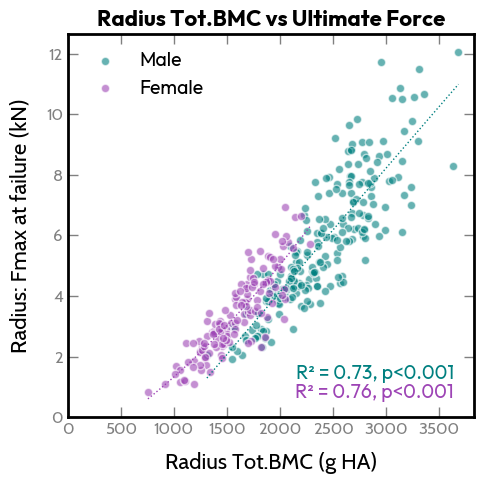

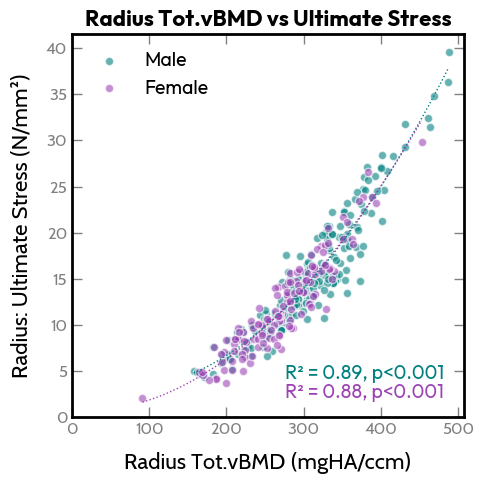

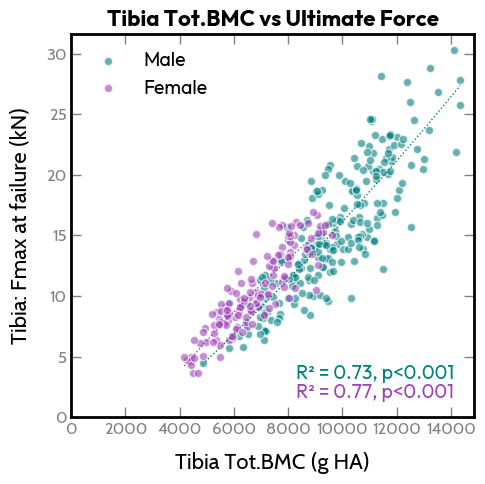

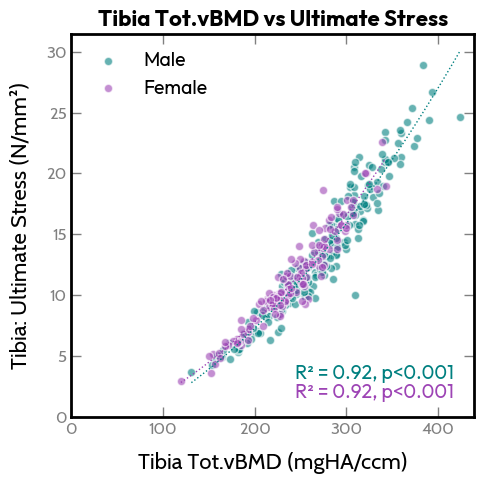

In [ ]:
radius_bmc = dataset.radius_bmc()
bmc_m = radius_bmc[db_stats.df["Gender"] == "Male"]
fmax_m = (
    db_stats.df.loc[db_stats.df["Gender"] == "Male", "Radius: Fmax at failure [N]"]
    / 1000
)
bmc_f = radius_bmc[db_stats.df["Gender"] == "Female"]
fmax_f = (
    db_stats.df.loc[db_stats.df["Gender"] == "Female", "Radius: Fmax at failure [N]"]
    / 1000
)

xlabel = "Radius Tot.BMC (g HA)"
ylabel = "Radius: Fmax at failure (kN)"
title = "Radius Tot.BMC vs Ultimate Force"
output_path = "output/radius_bmc_force.pdf"

plot_scatter_with_regression(
    bmc_m, fmax_m, bmc_f, fmax_f, xlabel, ylabel, title, output_path
)

yield_stress = dataset.Radius_ultimate_stress
bmd_m = db_stats.df["Radius: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Male"]
fmax_m = yield_stress[db_stats.df["Gender"] == "Male"]
bmd_f = db_stats.df["Radius: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Female"]
fmax_f = yield_stress[db_stats.df["Gender"] == "Female"]

xlabel = "Radius Tot.vBMD (mgHA/ccm)"
ylabel = "Radius: Ultimate Stress (N/mm²)"
title = "Radius Tot.vBMD vs Ultimate Stress"
output_path = "output/radius_bmd_stress.pdf"

plot_scatter_with_regression(
    bmd_m, fmax_m, bmd_f, fmax_f, xlabel, ylabel, title, output_path
)

tibia_bmc = dataset.tibia_bmc()
prop_x_m = tibia_bmc[db_stats.df["Gender"] == "Male"]
prop_y_m = (
    db_stats.df.loc[db_stats.df["Gender"] == "Male", "Tibia: Fmax at failure [N]"]
    / 1000
)
prop_x_f = tibia_bmc[db_stats.df["Gender"] == "Female"]
prop_y_f = (
    db_stats.df.loc[db_stats.df["Gender"] == "Female", "Tibia: Fmax at failure [N]"]
    / 1000
)

xlabel = "Tibia Tot.BMC (g HA)"
ylabel = "Tibia: Fmax at failure (kN)"
title = "Tibia Tot.BMC vs Ultimate Force"
output_path = "output/tibia_bmc_force.pdf"

plot_scatter_with_regression(
    prop_x_m, prop_y_m, prop_x_f, prop_y_f, xlabel, ylabel, title, output_path
)

prop_x_m = db_stats.df["Tibia: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Male"]
prop_y_m = dataset.Tibia_ultimate_stress[db_stats.df["Gender"] == "Male"]
prop_x_f = db_stats.df["Tibia: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Female"]
prop_y_f = dataset.Tibia_ultimate_stress[db_stats.df["Gender"] == "Female"]

xlabel = "Tibia Tot.vBMD (mgHA/ccm)"
ylabel = "Tibia: Ultimate Stress (N/mm²)"
title = "Tibia Tot.vBMD vs Ultimate Stress"
output_path = "output/tibia_bmd_stress.pdf"

plot_scatter_with_regression(
    prop_x_m, prop_y_m, prop_x_f, prop_y_f, xlabel, ylabel, title, output_path
)

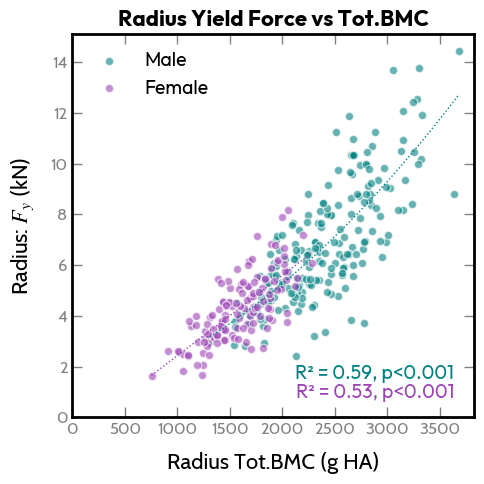

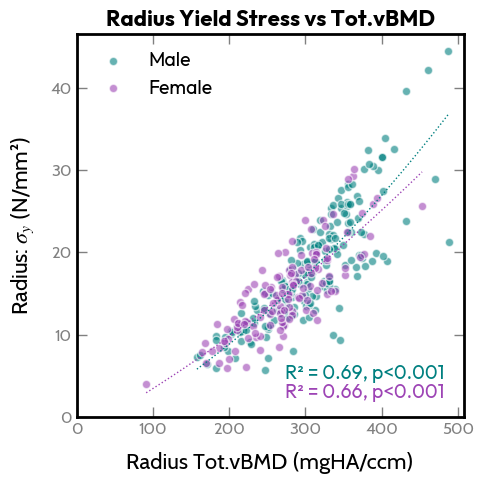

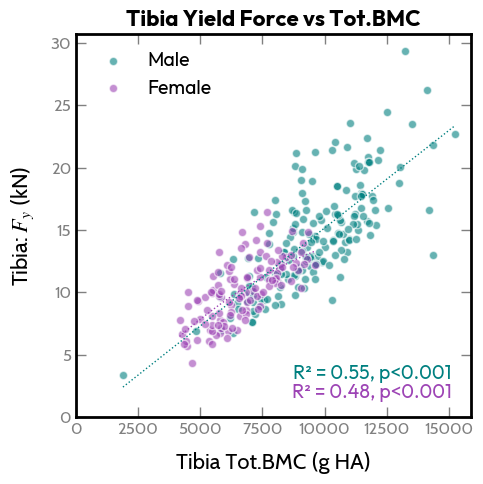

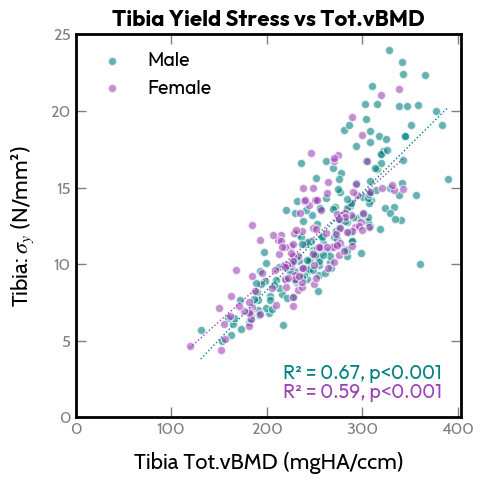

In [ ]:
##### USING HFE RESULTS #####

# 1. BMC vs Yield Force
# 2. BMD vs Yield Stress

radius_bmc = dataset.radius_bmc()
bmc_m = radius_bmc[db_stats.df["Gender"] == "Male"]
fmax_m = db_stats.df.loc[db_stats.df["Gender"] == "Male", "Radius: y.Force [N]"] / 1000
bmc_f = radius_bmc[db_stats.df["Gender"] == "Female"]
fmax_f = (
    db_stats.df.loc[db_stats.df["Gender"] == "Female", "Radius: y.Force [N]"] / 1000
)

xlabel = "Radius Tot.BMC (g HA)"
ylabel = "Radius: $F_y$ (kN)"
title = "Radius Yield Force vs Tot.BMC"
output_path = "output/hfe/radius_bmc_yield_force.pdf"

plot_scatter_with_regression(
    bmc_m, fmax_m, bmc_f, fmax_f, xlabel, ylabel, title, output_path
)


yield_stress = dataset.Radius_yield_stress
bmd_m = db_stats.df["Radius: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Male"]
fmax_m = yield_stress[db_stats.df["Gender"] == "Male"]
bmd_f = db_stats.df["Radius: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Female"]
fmax_f = yield_stress[db_stats.df["Gender"] == "Female"]

xlabel = "Radius Tot.vBMD (mgHA/ccm)"
ylabel = "Radius: $\sigma_y$ (N/mm²)"
title = "Radius Yield Stress vs Tot.vBMD"
output_path = "output/hfe/radius_bmd_yield_stress.pdf"

plot_scatter_with_regression(
    bmd_m, fmax_m, bmd_f, fmax_f, xlabel, ylabel, title, output_path
)

tibia_bmc = dataset.tibia_bmc()
prop_x_m = tibia_bmc[db_stats.df["Gender"] == "Male"]
prop_y_m = db_stats.df.loc[db_stats.df["Gender"] == "Male", "Tibia: y.Force [N]"] / 1000
prop_x_f = tibia_bmc[db_stats.df["Gender"] == "Female"]
prop_y_f = (
    db_stats.df.loc[db_stats.df["Gender"] == "Female", "Tibia: y.Force [N]"] / 1000
)

xlabel = "Tibia Tot.BMC (g HA)"
ylabel = "Tibia: $F_y$ (kN)"
title = "Tibia Yield Force vs Tot.BMC"
output_path = "output/hfe/tibia_bmc_yield_force.pdf"

plot_scatter_with_regression(
    prop_x_m, prop_y_m, prop_x_f, prop_y_f, xlabel, ylabel, title, output_path
)

prop_x_m = db_stats.df["Tibia: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Male"]
prop_y_m = dataset.Tibia_yield_stress[db_stats.df["Gender"] == "Male"]
prop_x_f = db_stats.df["Tibia: Tot.vBMD [mg HA/cmm]"][db_stats.df["Gender"] == "Female"]
prop_y_f = dataset.Tibia_yield_stress[db_stats.df["Gender"] == "Female"]

xlabel = "Tibia Tot.vBMD (mgHA/ccm)"
ylabel = "Tibia: $\sigma_y$ (N/mm²)"
title = "Tibia Yield Stress vs Tot.vBMD"
output_path = "output/hfe/tibia_bmd_yield_stress.pdf"

plot_scatter_with_regression(
    prop_x_m, prop_y_m, prop_x_f, prop_y_f, xlabel, ylabel, title, output_path
)

In [ ]:
def subplot_scatter_both_properties(
    intensive_prop_x_m,
    intensive_prop_y_m,
    intensive_prop_x_f,
    intensive_prop_y_f,
    intensive_xlabel,
    intensive_ylabel,
    intensive_title,
    intensive_output_path,
    extensive_prop_x_m,
    extensive_prop_y_m,
    extensive_prop_x_f,
    extensive_prop_y_f,
    extensive_xlabel,
    extensive_ylabel,
    extensive_title,
    extensive_output_path_ext,
):

    plt.style.use("../../01_CODE/src/style/paper-style.mplstyle")

    # Create subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # Function to plot on a specific axis
    def plot_on_axis(ax, x_m, y_m, x_f, y_f, xlabel, ylabel, title):
        # Remove NaN values for males
        valid_indices_m = x_m.notna() & y_m.notna()
        x_m_clean = x_m[valid_indices_m]
        y_m_clean = y_m[valid_indices_m]

        ax.scatter(
            x_m_clean,
            y_m_clean,
            c="#008080",
            alpha=0.6,
            edgecolors="white",
            label="Male",
        )

        # Fit polynomial regression model
        degree = 2
        coefficients_m = np.polyfit(x_m_clean, y_m_clean, degree)
        polynomial_m = np.poly1d(coefficients_m)

        x_range_m = np.linspace(x_m_clean.min(), x_m_clean.max(), 100)
        y_pred_m = polynomial_m(x_range_m)

        ax.plot(x_range_m, y_pred_m, color="#008080", linestyle=":", linewidth=1)

        # Calculate R²
        y_pred_m_full = polynomial_m(x_m_clean)
        ss_res_m = np.sum((y_m_clean - y_pred_m_full) ** 2)
        ss_tot_m = np.sum((y_m_clean - np.mean(y_m_clean)) ** 2)
        r_squared_m = 1 - (ss_res_m / ss_tot_m)

        # Calculate p-value for males
        x_m_poly = np.column_stack([x_m_clean**i for i in range(degree + 1)])
        model_m = sm.OLS(y_m_clean, x_m_poly).fit()
        p_value_m = model_m.f_pvalue

        # Remove NaN values for females
        valid_indices_f = x_f.notna() & y_f.notna()
        x_f_clean = x_f[valid_indices_f]
        y_f_clean = y_f[valid_indices_f]

        ax.scatter(
            x_f_clean,
            y_f_clean,
            c="#9D44B5",
            alpha=0.6,
            edgecolors="white",
            label="Female",
        )

        coefficients_f = np.polyfit(x_f_clean, y_f_clean, degree)
        polynomial_f = np.poly1d(coefficients_f)

        x_range_f = np.linspace(x_f_clean.min(), x_f_clean.max(), 100)
        y_pred_f = polynomial_f(x_range_f)

        ax.plot(x_range_f, y_pred_f, color="#9D44B5", linestyle=":", linewidth=1)

        # Calculate R²
        y_pred_f_full = polynomial_f(x_f_clean)
        ss_res_f = np.sum((y_f_clean - y_pred_f_full) ** 2)
        ss_tot_f = np.sum((y_f_clean - np.mean(y_f_clean)) ** 2)
        r_squared_f = 1 - (ss_res_f / ss_tot_f)

        # Calculate p-value for females
        x_f_poly = np.column_stack([x_f_clean**i for i in range(degree + 1)])
        model_f = sm.OLS(y_f_clean, x_f_poly).fit()
        p_value_f = model_f.f_pvalue

        ax.set_xlabel(xlabel, family="Cabin", fontsize=18)
        ax.set_ylabel(ylabel, family="Cabin", fontsize=18)
        ax.set_title(title, family="Outfit", weight="bold", fontsize=18)
        ax.tick_params(labelsize=18)
        ax.grid(False)
        ax.set_xlim(0)
        ax.set_ylim(0)

        # Text for males - with conditional p-value display
        if p_value_m < 0.001:
            ax.text(
                0.95,
                0.1,
                "R² = {:.2f}, p<0.001".format(r_squared_m),
                color="#008080",
                ha="right",
                transform=ax.transAxes,
                fontsize=14,
            )
        else:
            ax.text(
                0.95,
                0.1,
                "R² = {:.2f}, p = {:.1e}".format(r_squared_m, p_value_m),
                color="#008080",
                ha="right",
                transform=ax.transAxes,
                fontsize=14,
            )

        # Text for females - with conditional p-value display
        if p_value_f < 0.001:
            ax.text(
                0.95,
                0.05,
                "R² = {:.2f}, p<0.001".format(r_squared_f),
                color="#9D44B5",
                ha="right",
                transform=ax.transAxes,
                fontsize=14,
            )
        else:
            ax.text(
                0.95,
                0.05,
                "R² = {:.2f}, p = {:.1e}".format(r_squared_f, p_value_f),
                color="#9D44B5",
                ha="right",
                transform=ax.transAxes,
                fontsize=14,
            )

    # Plot extensive properties on the first subplot
    plot_on_axis(
        ax1,
        extensive_prop_x_m,
        extensive_prop_y_m,
        extensive_prop_x_f,
        extensive_prop_y_f,
        extensive_xlabel,
        extensive_ylabel,
        extensive_title,
    )
    ax1.legend(fontsize=18)

    # Plot intensive properties on the second subplot
    plot_on_axis(
        ax2,
        intensive_prop_x_m,
        intensive_prop_y_m,
        intensive_prop_x_f,
        intensive_prop_y_f,
        intensive_xlabel,
        intensive_ylabel,
        intensive_title,
    )
    ax2.legend(fontsize=18)

    # Save the combined plot
    plt.tight_layout()
    combined_output_path = "output/hfe/extensive_intensive_comparison.pdf"
    plt.savefig(combined_output_path, bbox_inches="tight", transparent=True)
    # plt.savefig(Path(combined_output_path).with_suffix('.png'), bbox_inches='tight', dpi=300)
    plt.show()

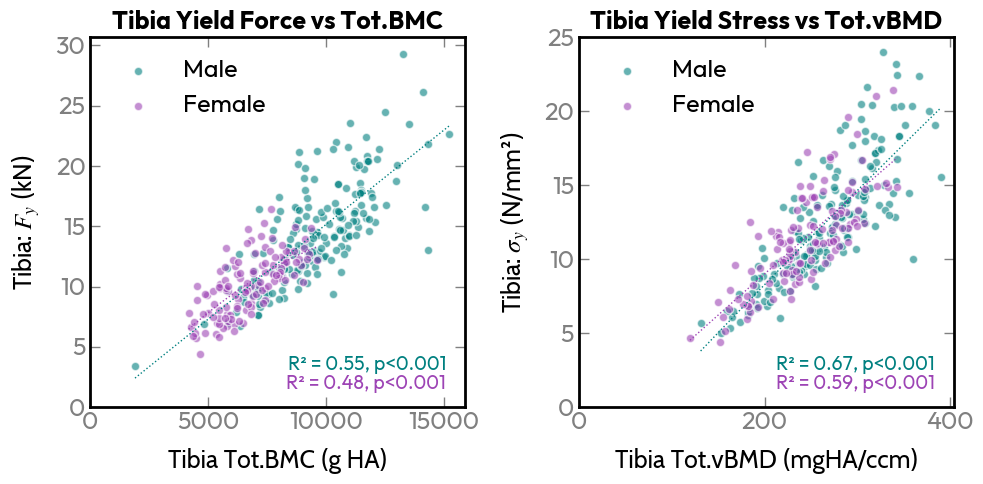

In [ ]:
# subplot for graphical abstract

#### Extensive properties ####
extensive_tibia_bmc = dataset.tibia_bmc()
extensive_prop_x_m = tibia_bmc[db_stats.df["Gender"] == "Male"]
extensive_prop_y_m = (
    db_stats.df.loc[db_stats.df["Gender"] == "Male", "Tibia: y.Force [N]"] / 1000
)
extensive_prop_x_f = tibia_bmc[db_stats.df["Gender"] == "Female"]
extensive_prop_y_f = (
    db_stats.df.loc[db_stats.df["Gender"] == "Female", "Tibia: y.Force [N]"] / 1000
)
extensive_xlabel = "Tibia Tot.BMC (g HA)"
extensive_ylabel = "Tibia: $F_y$ (kN)"
extensive_title = "Tibia Yield Force vs Tot.BMC"
extensive_output_path = "output/hfe/tibia_bmc_yield_force.pdf"


#### Intensive properties ####
intensive_prop_x_m = db_stats.df["Tibia: Tot.vBMD [mg HA/cmm]"][
    db_stats.df["Gender"] == "Male"
]
intensive_prop_y_m = dataset.Tibia_yield_stress[db_stats.df["Gender"] == "Male"]
intensive_prop_x_f = db_stats.df["Tibia: Tot.vBMD [mg HA/cmm]"][
    db_stats.df["Gender"] == "Female"
]
intensive_prop_y_f = dataset.Tibia_yield_stress[db_stats.df["Gender"] == "Female"]

intensive_xlabel = "Tibia Tot.vBMD (mgHA/ccm)"
intensive_ylabel = "Tibia: $\sigma_y$ (N/mm²)"
intensive_title = "Tibia Yield Stress vs Tot.vBMD"
intensive_output_path = "output/hfe/tibia_bmd_yield_stress.pdf"

subplot_scatter_both_properties(
    intensive_prop_x_m,
    intensive_prop_y_m,
    intensive_prop_x_f,
    intensive_prop_y_f,
    intensive_xlabel,
    intensive_ylabel,
    intensive_title,
    intensive_output_path,
    extensive_prop_x_m,
    extensive_prop_y_m,
    extensive_prop_x_f,
    extensive_prop_y_f,
    extensive_xlabel,
    extensive_ylabel,
    extensive_title,
    extensive_output_path,
)